In [1]:
import pandas as pd

df =pd.read_csv('../data/raw/github_issues.csv')
print(df.columns)

kolom_pilihan = ['number', 'title', 'state', 'created_at', 'closed_at', 'labels']
df = df[kolom_pilihan]

df['created_at'] = pd.to_datetime(df['created_at'])
df['closed_at'] = pd.to_datetime(df['closed_at'])

df['duration_days'] = (df['closed_at'] - df['created_at']).dt.total_seconds() / 86400

df = df.dropna(subset=['closed_at'])

df.to_csv('../data/clean/database_final.csv', index=False)

Index(['url', 'repository_url', 'labels_url', 'comments_url', 'events_url',
       'html_url', 'id', 'node_id', 'number', 'title', 'user', 'labels',
       'state', 'locked', 'assignees', 'milestone', 'comments', 'created_at',
       'updated_at', 'closed_at', 'assignee', 'author_association',
       'issue_field_values', 'type', 'active_lock_reason', 'draft',
       'pull_request', 'body', 'closed_by', 'reactions', 'timeline_url',
       'performed_via_github_app', 'state_reason', 'sub_issues_summary',
       'issue_dependencies_summary', 'pinned_comment'],
      dtype='str')


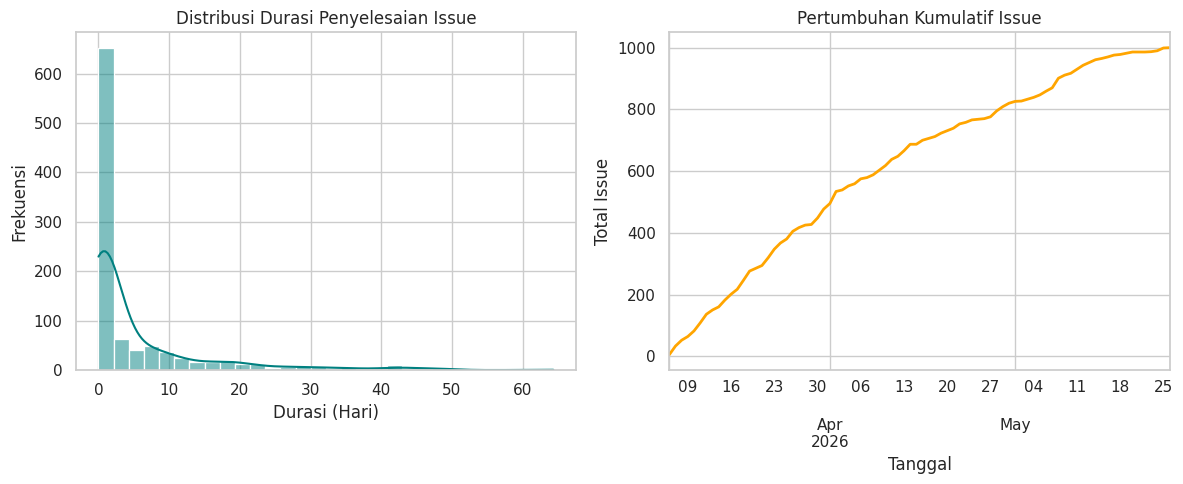

------------------------------
STATISTIK DESKRIPTIF UNTUK MEMBER B:
count    1000.000000
mean        5.345638
std         9.597467
min         0.000150
25%         0.277717
50%         0.935816
75%         6.240301
max        64.343866
Name: duration_days, dtype: float64
------------------------------


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# GRAFIK 1: Distribusi Waktu Penyelesaian (Histogram)
plt.subplot(1, 2, 1)
sns.histplot(df_clean['duration_days'], bins=30, kde=True, color='teal')
plt.title('Distribusi Durasi Penyelesaian Issue', fontsize=12)
plt.xlabel('Durasi (Hari)')
plt.ylabel('Frekuensi')

# GRAFIK 2: Tren Kumulatif Issue Dibuat (Time Series)
plt.subplot(1, 2, 2) # Grafik kanan
df_clean.set_index('created_at').resample('D').size().cumsum().plot(color='orange', lw=2)
plt.title('Pertumbuhan Kumulatif Issue', fontsize=12)
plt.xlabel('Tanggal')
plt.ylabel('Total Issue')

plt.tight_layout()
plt.show()

print("-" * 30)
print("STATISTIK DESKRIPTIF UNTUK MEMBER B:")
print(df_clean['duration_days'].describe())
print("-" * 30)

In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/github_issues.csv')

df_clean = df[['number', 'title', 'state', 'created_at', 'closed_at']].copy()

df_clean['created_at'] = pd.to_datetime(df_clean['created_at'])
df_clean['closed_at'] = pd.to_datetime(df_clean['closed_at'])

df_clean['duration_days'] = (df_clean['closed_at'] - df_clean['created_at']).dt.total_seconds() / 86400

df_clean = df_clean.dropna(subset=['duration_days'])